<a href="https://colab.research.google.com/github/mohansharma077/amr_mobilenet/blob/main/AMR_30K_Cells.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training Pipeline: MobileNetV2 and DenseNet121


## Part 1: Setup and Configuration

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages
!pip install -q imagecodecs tifffile scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 77.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tifffile
import cv2
from skimage import exposure
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2, DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU configured: {gpus}")

TensorFlow version: 2.19.0
GPU available: True
GPU configured: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Configuration
BASE_PATH = '/content/drive/MyDrive/amr'
MG1655_PATH = Path(BASE_PATH) / 'MG1655'
OUTPUT_DIR = Path(BASE_PATH) / 'full_training_results'
CACHE_DIR = Path('/content/cache')

OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / 'models').mkdir(exist_ok=True)
(OUTPUT_DIR / 'figures').mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

# Extract all available cells (aim for 30,000)
TARGET_CELLS_PER_CLASS = 15000
TARGET_SIZE = 64
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Dataset path: {MG1655_PATH}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Target cells: {TARGET_CELLS_PER_CLASS * 2}")

Dataset path: /content/drive/MyDrive/amr/MG1655
Output directory: /content/drive/MyDrive/amr/full_training_results
Target cells: 30000


## Part 2: Data Extraction

In [ ]:
class DatasetExtractor:
    def __init__(self, base_path, target_cells_per_class, target_size, cache_dir):
        self.base_path = Path(base_path)
        self.target_cells = target_cells_per_class
        self.target_size = target_size
        self.cache_file = Path(cache_dir) / 'full_dataset_30k.npz'

    def parse_image(self, img):
        """Extract DAPI and Nile Red channels"""
        if img.ndim == 3 and img.shape[2] == 3:
            dapi = img[:, :, 0][None, :, :]
            nile_red = img[:, :, 1][None, :, :]
            return dapi, nile_red
        elif img.ndim == 3 and img.shape[0] == 3:
            dapi = img[0:1, :, :]
            nile_red = img[1:2, :, :]
            return dapi, nile_red
        else:
            raise ValueError(f"Unexpected image shape: {img.shape}")

    def parse_mask(self, mask):
        """Extract individual cell masks"""
        if mask.ndim == 2:
            cell_ids = np.unique(mask)
            cell_ids = cell_ids[cell_ids != 0]
            return [(mask == cid) for cid in cell_ids]
        elif mask.ndim == 3:
            return [mask[:, :, i] for i in range(mask.shape[2])]
        else:
            raise ValueError(f"Unexpected mask shape: {mask.shape}")

    def extract_cell(self, dapi_stack, nile_red_stack, cell_mask):
        """Extract and preprocess single cell"""
        if dapi_stack.shape[0] > 1:
            dapi_avg = np.mean(dapi_stack, axis=0)
            nile_red_avg = np.mean(nile_red_stack, axis=0)
        else:
            dapi_avg = dapi_stack[0]
            nile_red_avg = nile_red_stack[0]

        try:
            shift, _ = cv2.phaseCorrelate(
                nile_red_avg.astype(np.float32),
                dapi_avg.astype(np.float32)
            )
            M = np.float32([[1, 0, shift[0]], [0, 1, shift[1]]])
            dapi_reg = cv2.warpAffine(dapi_avg, M, (dapi_avg.shape[1], dapi_avg.shape[0]))
        except:
            dapi_reg = dapi_avg

        coords = np.argwhere(cell_mask)
        if len(coords) < 10:
            return None

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        pad = 2
        y_min = max(0, y_min - pad)
        x_min = max(0, x_min - pad)
        y_max = min(dapi_reg.shape[0], y_max + pad)
        x_max = min(dapi_reg.shape[1], x_max + pad)

        dapi_crop = dapi_reg[y_min:y_max+1, x_min:x_max+1]
        nile_red_crop = nile_red_avg[y_min:y_max+1, x_min:x_max+1]
        mask_crop = cell_mask[y_min:y_max+1, x_min:x_max+1]

        h, w = dapi_crop.shape
        if h < self.target_size or w < self.target_size:
            pad_h = max(0, self.target_size - h)
            pad_w = max(0, self.target_size - w)
            dapi_crop = np.pad(dapi_crop, ((0, pad_h), (0, pad_w)), mode='constant')
            nile_red_crop = np.pad(nile_red_crop, ((0, pad_h), (0, pad_w)), mode='constant')
            mask_crop = np.pad(mask_crop, ((0, pad_h), (0, pad_w)), mode='constant')

        dapi_resized = cv2.resize(
            dapi_crop[:self.target_size, :self.target_size],
            (self.target_size, self.target_size)
        ) if dapi_crop.shape[0] != self.target_size else dapi_crop[:self.target_size, :self.target_size]

        nile_red_resized = cv2.resize(
            nile_red_crop[:self.target_size, :self.target_size],
            (self.target_size, self.target_size)
        ) if nile_red_crop.shape[0] != self.target_size else nile_red_crop[:self.target_size, :self.target_size]

        mask_resized = cv2.resize(
            mask_crop[:self.target_size, :self.target_size].astype(np.uint8),
            (self.target_size, self.target_size),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool) if mask_crop.shape[0] != self.target_size else mask_crop[:self.target_size, :self.target_size]

        rgb = np.zeros((self.target_size, self.target_size, 3), dtype=np.float32)
        rgb[:, :, 0] = nile_red_resized
        rgb[:, :, 1] = dapi_resized

        for ch in range(2):
            pixels = rgb[:, :, ch][mask_resized]
            if len(pixels) > 10:
                pmin, pmax = pixels.min(), pixels.max()
                if pmax > pmin:
                    norm = (pixels - pmin) / (pmax - pmin)
                    try:
                        equalized = exposure.equalize_hist(norm)
                        rgb[:, :, ch][mask_resized] = equalized
                    except:
                        rgb[:, :, ch][mask_resized] = norm

        rgb = np.clip(rgb * 255, 0, 255).astype(np.uint8)
        return rgb

    def extract_dataset(self):
        """Extract complete dataset"""
        if self.cache_file.exists():
            print(f"Loading from cache: {self.cache_file}")
            data = np.load(self.cache_file, allow_pickle=True)
            dataset = {'images': data['images'], 'labels': data['labels']}
            print(f"Loaded {len(dataset['images'])} cells from cache")
            return dataset

        dataset = {'images': [], 'labels': []}

        # Extract resistant cells
        print(f"\nExtracting resistant cells (target: {self.target_cells})")
        resistant_folder = self.base_path / "All_images" / "WT+ETOH"
        resistant_masks = self.base_path / "All_segmentations" / "WT+ETOH"
        img_files = sorted(list(resistant_folder.glob('*.tif*')))

        cells_extracted = 0
        for img_file in tqdm(img_files, desc="Processing resistant"):
            if cells_extracted >= self.target_cells:
                break
            try:
                img = tifffile.imread(str(img_file))
                mask = tifffile.imread(str(resistant_masks / img_file.name))
                dapi, nile_red = self.parse_image(img)
                cell_masks = self.parse_mask(mask)

                for cell_mask in cell_masks:
                    if cells_extracted >= self.target_cells:
                        break
                    cell_img = self.extract_cell(dapi, nile_red, cell_mask)
                    if cell_img is not None:
                        dataset['images'].append(cell_img)
                        dataset['labels'].append(0)
                        cells_extracted += 1
            except Exception as e:
                continue

        print(f"Extracted {cells_extracted} resistant cells")

        # Extract susceptible cells
        print(f"\nExtracting susceptible cells (target: {self.target_cells})")
        susceptible_folder = self.base_path / "All_images" / "CIP+ETOH"
        susceptible_masks = self.base_path / "All_segmentations" / "CIP+ETOH"
        img_files = sorted(list(susceptible_folder.glob('*.tif*')))

        cells_extracted = 0
        for img_file in tqdm(img_files, desc="Processing susceptible"):
            if cells_extracted >= self.target_cells:
                break
            try:
                img = tifffile.imread(str(img_file))
                mask = tifffile.imread(str(susceptible_masks / img_file.name))
                dapi, nile_red = self.parse_image(img)
                cell_masks = self.parse_mask(mask)

                for cell_mask in cell_masks:
                    if cells_extracted >= self.target_cells:
                        break
                    cell_img = self.extract_cell(dapi, nile_red, cell_mask)
                    if cell_img is not None:
                        dataset['images'].append(cell_img)
                        dataset['labels'].append(1)
                        cells_extracted += 1
            except Exception as e:
                continue

        print(f"Extracted {cells_extracted} susceptible cells")

        dataset['images'] = np.array(dataset['images'])
        dataset['labels'] = np.array(dataset['labels'])

        print(f"\nTotal cells: {len(dataset['images'])}")
        print(f"Resistant: {np.sum(dataset['labels']==0)}")
        print(f"Susceptible: {np.sum(dataset['labels']==1)}")

        np.savez_compressed(self.cache_file, images=dataset['images'], labels=dataset['labels'])
        print(f"\nDataset cached to {self.cache_file}")

        return dataset

In [ ]:
# Extract dataset
extractor = DatasetExtractor(MG1655_PATH, TARGET_CELLS_PER_CLASS, TARGET_SIZE, CACHE_DIR)
dataset = extractor.extract_dataset()

# Save to output directory
np.savez_compressed(OUTPUT_DIR / 'full_dataset_30k.npz',
                    images=dataset['images'],
                    labels=dataset['labels'])
print(f"\nDataset saved to {OUTPUT_DIR / 'full_dataset_30k.npz'}")


Extracting resistant cells (target: 15000)


Processing resistant:   0%|          | 0/455 [00:00<?, ?it/s]WARNING:tifffile:<tifffile.TiffFile '200818_1_MG1655_…ETOH_posXY0.tif'> shaped series metadata does not match page shape (684, 420, 3) != (3, 684, 420)
ERROR:tifffile:<tifffile.TiffFile '200818_1_MG1655_…ETOH_posXY0.tif'> invalid shaped series metadata or corrupted file
Processing resistant:  52%|█████▏    | 235/455 [04:30<04:13,  1.15s/it]


Extracted 15000 resistant cells

Extracting susceptible cells (target: 15000)


Processing susceptible:  99%|█████████▊| 281/285 [04:55<00:04,  1.05s/it]


Extracted 15000 susceptible cells

Total cells: 30000
Resistant: 15000
Susceptible: 15000

Dataset cached to /content/cache/full_dataset_30k.npz

Dataset saved to /content/drive/MyDrive/amr/full_training_results/full_dataset_30k.npz


## Part 3: Data Preparation

In [ ]:
# Load and prepare data
X = dataset['images']
y = dataset['labels']

print(f"Dataset shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Resistant: {np.sum(y==0)}")
print(f"Susceptible: {np.sum(y==1)}")

# Split: 70% train, 15% val, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Normalize
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, 2)
y_val_cat = tf.keras.utils.to_categorical(y_val, 2)
y_test_cat = tf.keras.utils.to_categorical(y_test, 2)

print(f"\nData splits:")
print(f"Train: {len(X_train)} ({np.sum(y_train==0)}R, {np.sum(y_train==1)}S)")
print(f"Val:   {len(X_val)} ({np.sum(y_val==0)}R, {np.sum(y_val==1)}S)")
print(f"Test:  {len(X_test)} ({np.sum(y_test==0)}R, {np.sum(y_test==1)}S)")

Dataset shape: (30000, 64, 64, 3)
Labels shape: (30000,)
Resistant: 15000
Susceptible: 15000

Data splits:
Train: 21000 (10500R, 10500S)
Val:   4500 (2250R, 2250S)
Test:  4500 (2250R, 2250S)


In [ ]:
# Setup data augmentation
augmentation = ImageDataGenerator(
    rotation_range=90,
    horizontal_flip=True,
    vertical_flip=True
)

print("Data augmentation configured")

Data augmentation configured


## Part 4: Model Definitions

In [ ]:
def build_mobilenet_model():
    """Build MobileNetV2 model"""
    base = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(64, 64, 3),
        alpha=1.0
    )
    base.trainable = True

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs, name='MobileNetV2')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')]
    )

    return model

def build_densenet_model():
    """Build DenseNet121 model"""
    base = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(64, 64, 3)
    )
    base.trainable = True

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(2, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=outputs, name='DenseNet121')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')]
    )

    return model

print("Model builders defined")

Model builders defined


## Part 5: Train MobileNetV2

In [ ]:
print("Building MobileNetV2 model")
model_mobile = build_mobilenet_model()

print(f"\nTotal parameters: {model_mobile.count_params():,}")
trainable = sum([tf.keras.backend.count_params(w) for w in model_mobile.trainable_weights])
print(f"Trainable parameters: {trainable:,}")

Building MobileNetV2 model

Total parameters: 2,586,434
Trainable parameters: 2,552,322


In [ ]:
# Callbacks for MobileNetV2
callbacks_mobile = [
    ModelCheckpoint(
        filepath=str(OUTPUT_DIR / 'models' / 'mobilenet_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured for MobileNetV2")

Callbacks configured for MobileNetV2


In [ ]:
print("Training MobileNetV2")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")

history_mobile = model_mobile.fit(
    augmentation.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=callbacks_mobile,
    verbose=1,
    steps_per_epoch=len(X_train) // BATCH_SIZE
)

print("\nMobileNetV2 training complete")

# Save final model and history
model_mobile.save(OUTPUT_DIR / 'models' / 'mobilenet_final.h5')
pd.DataFrame(history_mobile.history).to_csv(OUTPUT_DIR / 'history_mobilenet.csv', index=False)
print("MobileNetV2 model and history saved")

Training MobileNetV2
Training samples: 21000
Validation samples: 4500
Batch size: 64
Max epochs: 50
Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5492 - auc: 0.5719 - loss: 0.9172 - precision: 0.5492 - recall: 0.5492
Epoch 1: val_accuracy improved from -inf to 0.62756, saving model to /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 152s 284ms/step - accuracy: 0.5493 - auc: 0.5720 - loss: 0.9168 - precision: 0.5493 - recall: 0.5493 - val_accuracy: 0.6276 - val_auc: 0.6828 - val_loss: 0.6386 - val_precision: 0.6276 - val_recall: 0.6276 - learning_rate: 1.0000e-04
Epoch 2/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.6719 - auc: 0.7025 - loss: 0.6433 - precision: 0.6719 - recall: 0.6719
Epoch 2: val_accuracy improved from 0.62756 to 0.62800, saving model to /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6719 - auc: 0.7025 - loss: 0.6433 - precision: 0.6719 - recall: 0.6719 - val_accuracy: 0.6280 - val_auc: 0.6831 - val_loss: 0.6384 - val_precision: 0.6280 - val_recall: 0.6280 - learning_rate: 1.0000e-04
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.6566 - auc: 0.7213 - loss: 0.6353 - precision: 0.6566 - recall: 0.6566
Epoch 3: val_accuracy did not improve from 0.62800
328/328 ━━━━━━━━━━━━━━━━━━━━ 33s 101ms/step - accuracy: 0.6566 - auc: 0.7213 - loss: 0.6352 - precision: 0.6566 - recall: 0.6566 - val_accuracy: 0.6036 - val_auc: 0.6807 - val_loss: 0.7569 - val_precision: 0.6036 - val_recall: 0.6036 - learning_rate: 1.0000e-04
Epoch 4/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.7031 - auc: 0.7749 - loss: 0.5646 - precision: 0.7031 - recall: 0.7031
Epoch 4: val_accuracy did not improve from 0.62800
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7031 - auc: 0.7749 - loss: 0.5646 - precision

328/328 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.7274 - auc: 0.8051 - loss: 0.5414 - precision: 0.7274 - recall: 0.7274 - val_accuracy: 0.7491 - val_auc: 0.8330 - val_loss: 0.5044 - val_precision: 0.7491 - val_recall: 0.7491 - learning_rate: 1.0000e-04
Epoch 6/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 13s 42ms/step - accuracy: 0.7500 - auc: 0.7977 - loss: 0.5718 - precision: 0.7500 - recall: 0.7500
Epoch 6: val_accuracy did not improve from 0.74911
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7500 - auc: 0.7977 - loss: 0.5718 - precision: 0.7500 - recall: 0.7500 - val_accuracy: 0.7484 - val_auc: 0.8335 - val_loss: 0.5041 - val_precision: 0.7484 - val_recall: 0.7484 - learning_rate: 1.0000e-04
Epoch 7/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.7557 - auc: 0.8439 - loss: 0.4931 - precision: 0.7557 - recall: 0.7557
Epoch 7: val_accuracy improved from 0.74911 to 0.77711, saving model to /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 36s 111ms/step - accuracy: 0.7557 - auc: 0.8439 - loss: 0.4931 - precision: 0.7557 - recall: 0.7557 - val_accuracy: 0.7771 - val_auc: 0.8621 - val_loss: 0.4739 - val_precision: 0.7771 - val_recall: 0.7771 - learning_rate: 1.0000e-04
Epoch 8/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8125 - auc: 0.8870 - loss: 0.4451 - precision: 0.8125 - recall: 0.8125
Epoch 8: val_accuracy improved from 0.77711 to 0.77800, saving model to /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5


...

328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8750 - auc: 0.9445 - loss: 0.3097 - precision: 0.8750 - recall: 0.8750 - val_accuracy: 0.8436 - val_auc: 0.9279 - val_loss: 0.3505 - val_precision: 0.8436 - val_recall: 0.8436 - learning_rate: 1.2500e-05
Epoch 31/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8328 - auc: 0.9178 - loss: 0.3633 - precision: 0.8328 - recall: 0.8328
Epoch 31: val_accuracy improved from 0.84356 to 0.84400, saving model to /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - accuracy: 0.8329 - auc: 0.9178 - loss: 0.3632 - precision: 0.8329 - recall: 0.8329 - val_accuracy: 0.8440 - val_auc: 0.9274 - val_loss: 0.3628 - val_precision: 0.8440 - val_recall: 0.8440 - learning_rate: 1.2500e-05
Epoch 32/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.8906 - auc: 0.9470 - loss: 0.2998 - precision: 0.8906 - recall: 0.8906
Epoch 32: val_accuracy improved from 0.84400 to 0.84444, saving model to /content/drive/MyDrive/amr/full_training_results/models/mobilenet_best.h5



Epoch 32: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8906 - auc: 0.9470 - loss: 0.2998 - precision: 0.8906 - recall: 0.8906 - val_accuracy: 0.8444 - val_auc: 0.9274 - val_loss: 0.3627 - val_precision: 0.8444 - val_recall: 0.8444 - learning_rate: 1.2500e-05
Epoch 33/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.8331 - auc: 0.9201 - loss: 0.3591 - precision: 0.8331 - recall: 0.8331
Epoch 33: val_accuracy did not improve from 0.84444
328/328 ━━━━━━━━━━━━━━━━━━━━ 34s 105ms/step - accuracy: 0.8331 - auc: 0.9201 - loss: 0.3590 - precision: 0.8331 - recall: 0.8331 - val_accuracy: 0.8429 - val_auc: 0.9269 - val_loss: 0.3627 - val_precision: 0.8429 - val_recall: 0.8429 - learning_rate: 6.2500e-06
Epoch 34/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.7188 - auc: 0.8896 - loss: 0.3762 - precision: 0.7188 - recall: 0.7188
Epoch 34: val_accuracy did not improve from 0.84444
328/328 ━━━━━━━━━━━

328/328 ━━━━━━━━━━━━━━━━━━━━ 38s 115ms/step - accuracy: 0.8383 - auc: 0.9243 - loss: 0.3505 - precision: 0.8383 - recall: 0.8383 - val_accuracy: 0.8451 - val_auc: 0.9285 - val_loss: 0.3573 - val_precision: 0.8451 - val_recall: 0.8451 - learning_rate: 1.5625e-06
Epoch 40/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 15s 46ms/step - accuracy: 0.8750 - auc: 0.9381 - loss: 0.3159 - precision: 0.8750 - recall: 0.8750
Epoch 40: val_accuracy did not improve from 0.84511
328/328 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8750 - auc: 0.9381 - loss: 0.3159 - precision: 0.8750 - recall: 0.8750 - val_accuracy: 0.8451 - val_auc: 0.9285 - val_loss: 0.3573 - val_precision: 0.8451 - val_recall: 0.8451 - learning_rate: 1.5625e-06
Epoch 40: early stopping
Restoring model weights from the end of the best epoch: 30.



MobileNetV2 training complete
MobileNetV2 model and history saved


## Part 6: Evaluate MobileNetV2

In [ ]:
# Load best MobileNetV2 model
best_mobile = tf.keras.models.load_model(OUTPUT_DIR / 'models' / 'mobilenet_best.h5')

print("Evaluating MobileNetV2 on test set")
results_mobile = best_mobile.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nMobileNetV2 Test Results:")
print(f"Loss: {results_mobile[0]:.4f}")
print(f"Accuracy: {results_mobile[1]*100:.2f}%")
print(f"Precision: {results_mobile[2]:.4f}")
print(f"Recall: {results_mobile[3]:.4f}")
print(f"AUC: {results_mobile[4]:.4f}")

# Predictions
y_pred_probs_mobile = best_mobile.predict(X_test, verbose=0)
y_pred_mobile = np.argmax(y_pred_probs_mobile, axis=1)

# Per-class metrics
precision_m, recall_m, f1_m, support_m = precision_recall_fscore_support(
    y_test, y_pred_mobile, average=None
)

print(f"\nPer-class performance:")
print(f"Resistant: Precision={precision_m[0]:.3f}, Recall={recall_m[0]:.3f}, F1={f1_m[0]:.3f}")
print(f"Susceptible: Precision={precision_m[1]:.3f}, Recall={recall_m[1]:.3f}, F1={f1_m[1]:.3f}")

# Save predictions
np.savez(OUTPUT_DIR / 'predictions_mobilenet.npz',
         y_true=y_test, y_pred=y_pred_mobile, y_pred_probs=y_pred_probs_mobile)

Evaluating MobileNetV2 on test set
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8442 - auc: 0.9307 - loss: 0.3518 - precision: 0.8442 - recall: 0.8442

MobileNetV2 Test Results:
Loss: 0.3633
Accuracy: 83.67%
Precision: 0.8367
Recall: 0.8367
AUC: 0.9255

Per-class performance:
Resistant: Precision=0.858, Recall=0.807, F1=0.832
Susceptible: Precision=0.818, Recall=0.866, F1=0.841


## Part 7: Train DenseNet121

In [ ]:
print("Building DenseNet121 model")
model_dense = build_densenet_model()

print(f"\nTotal parameters: {model_dense.count_params():,}")
trainable = sum([tf.keras.backend.count_params(w) for w in model_dense.trainable_weights])
print(f"Trainable parameters: {trainable:,}")

Building DenseNet121 model
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Total parameters: 7,305,538
Trainable parameters: 7,219,330


In [ ]:
# Callbacks for DenseNet121
callbacks_dense = [
    ModelCheckpoint(
        filepath=str(OUTPUT_DIR / 'models' / 'densenet_best.h5'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks configured for DenseNet121")

Callbacks configured for DenseNet121


In [ ]:
print("Training DenseNet121")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Max epochs: {EPOCHS}")

history_dense = model_dense.fit(
    augmentation.flow(X_train, y_train_cat, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    callbacks=callbacks_dense,
    verbose=1,
    steps_per_epoch=len(X_train) // BATCH_SIZE
)

print("\nDenseNet121 training complete")

# Save final model and history
model_dense.save(OUTPUT_DIR / 'models' / 'densenet_final.h5')
pd.DataFrame(history_dense.history).to_csv(OUTPUT_DIR / 'history_densenet.csv', index=False)
print("DenseNet121 model and history saved")

Training DenseNet121
Training samples: 21000
Validation samples: 4500
Batch size: 64
Max epochs: 50
Epoch 1/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - accuracy: 0.6025 - auc: 0.6526 - loss: 0.8674 - precision: 0.6025 - recall: 0.6025
Epoch 1: val_accuracy improved from -inf to 0.73800, saving model to /content/drive/MyDrive/amr/full_training_results/models/densenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 321s 497ms/step - accuracy: 0.6027 - auc: 0.6528 - loss: 0.8670 - precision: 0.6027 - recall: 0.6027 - val_accuracy: 0.7380 - val_auc: 0.8290 - val_loss: 0.6127 - val_precision: 0.7380 - val_recall: 0.7380 - learning_rate: 1.0000e-04
Epoch 2/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 45s 138ms/step - accuracy: 0.6250 - auc: 0.7537 - loss: 0.6389 - precision: 0.6250 - recall: 0.6250
Epoch 2: val_accuracy did not improve from 0.73800
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6250 - auc: 0.7537 - loss: 0.6389 - precision: 0.6250 - recall: 0.6250 - val_accuracy: 0.7371 - val_auc: 0.8285 - val_loss: 0.6123 - val_precision: 0.7371 - val_recall: 0.7371 - learning_rate: 1.0000e-04
Epoch 3/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.7560 - auc: 0.8421 - loss: 0.5444 - precision: 0.7560 - recall: 0.7560
Epoch 3: val_accuracy improved from 0.73800 to 0.82067, saving model to /content/drive/MyDrive/amr/full_training_results/models/densenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 47s 143ms/step - accuracy: 0.7560 - auc: 0.8421 - loss: 0.5443 - precision: 0.7560 - recall: 0.7560 - val_accuracy: 0.8207 - val_auc: 0.9069 - val_loss: 0.3894 - val_precision: 0.8207 - val_recall: 0.8207 - learning_rate: 1.0000e-04
Epoch 4/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 34s 107ms/step - accuracy: 0.7500 - auc: 0.8571 - loss: 0.4667 - precision: 0.7500 - recall: 0.7500
Epoch 4: val_accuracy improved from 0.82067 to 0.82133, saving model to /content/drive/MyDrive/amr/full_training_results/models/densenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7500 - auc: 0.8571 - loss: 0.4667 - precision: 0.7500 - recall: 0.7500 - val_accuracy: 0.8213 - val_auc: 0.9068 - val_loss: 0.3895 - val_precision: 0.8213 - val_recall: 0.8213 - learning_rate: 1.0000e-04
Epoch 5/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.7972 - auc: 0.8868 - loss: 0.4402 - precision: 0.7972 - recall: 0.7972
Epoch 5: val_accuracy did not improve from 0.82133
328/328 ━━━━━━━━━━━━━━━━━━━━ 43s 131ms/step - accuracy: 0.7972 - auc: 0.8868 - loss: 0.4402 - precision: 0.7972 - recall: 0.7972 - val_accuracy: 0.7778 - val_auc: 0.8689 - val_loss: 0.5102 - val_precision: 0.7778 - val_recall: 0.7778 - learning_rate: 1.0000e-04
Epoch 6/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step - accuracy: 0.8281 - auc: 0.9102 - loss: 0.3822 - precision: 0.8281 - recall: 0.8281
Epoch 6: val_accuracy did not improve from 0.82133

Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
328/328 ━━━━━━━━━━━━━

328/328 ━━━━━━━━━━━━━━━━━━━━ 86s 152ms/step - accuracy: 0.8204 - auc: 0.9092 - loss: 0.3853 - precision: 0.8204 - recall: 0.8204 - val_accuracy: 0.8364 - val_auc: 0.9223 - val_loss: 0.3533 - val_precision: 0.8364 - val_recall: 0.8364 - learning_rate: 5.0000e-05
Epoch 8/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 35s 108ms/step - accuracy: 0.8281 - auc: 0.9092 - loss: 0.3858 - precision: 0.8281 - recall: 0.8281
Epoch 8: val_accuracy did not improve from 0.83644
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8281 - auc: 0.9092 - loss: 0.3858 - precision: 0.8281 - recall: 0.8281 - val_accuracy: 0.8360 - val_auc: 0.9227 - val_loss: 0.3523 - val_precision: 0.8360 - val_recall: 0.8360 - learning_rate: 5.0000e-05
Epoch 9/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8310 - auc: 0.9188 - loss: 0.3634 - precision: 0.8310 - recall: 0.8310
Epoch 9: val_accuracy improved from 0.83644 to 0.85333, saving model to /content/drive/MyDrive/amr/full_training_results/models/densenet_best.h5


...

328/328 ━━━━━━━━━━━━━━━━━━━━ 47s 145ms/step - accuracy: 0.8777 - auc: 0.9537 - loss: 0.2752 - precision: 0.8777 - recall: 0.8777 - val_accuracy: 0.8896 - val_auc: 0.9606 - val_loss: 0.2571 - val_precision: 0.8896 - val_recall: 0.8896 - learning_rate: 1.2500e-05
Epoch 32/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 35s 107ms/step - accuracy: 0.8750 - auc: 0.9331 - loss: 0.3398 - precision: 0.8750 - recall: 0.8750
Epoch 32: val_accuracy did not improve from 0.88956

Epoch 32: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-06.
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8750 - auc: 0.9331 - loss: 0.3398 - precision: 0.8750 - recall: 0.8750 - val_accuracy: 0.8891 - val_auc: 0.9605 - val_loss: 0.2573 - val_precision: 0.8891 - val_recall: 0.8891 - learning_rate: 1.2500e-05
Epoch 33/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.8795 - auc: 0.9557 - loss: 0.2682 - precision: 0.8795 - recall: 0.8795
Epoch 33: val_accuracy did not improve from 0.88956
328/328 ━━━━━━━━━

328/328 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.8801 - auc: 0.9553 - loss: 0.2700 - precision: 0.8801 - recall: 0.8801 - val_accuracy: 0.8922 - val_auc: 0.9631 - val_loss: 0.2487 - val_precision: 0.8922 - val_recall: 0.8922 - learning_rate: 6.2500e-06
Epoch 38/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 34s 106ms/step - accuracy: 0.8906 - auc: 0.9656 - loss: 0.2366 - precision: 0.8906 - recall: 0.8906
Epoch 38: val_accuracy did not improve from 0.89222
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8906 - auc: 0.9656 - loss: 0.2366 - precision: 0.8906 - recall: 0.8906 - val_accuracy: 0.8916 - val_auc: 0.9631 - val_loss: 0.2487 - val_precision: 0.8916 - val_recall: 0.8916 - learning_rate: 6.2500e-06
Epoch 39/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8776 - auc: 0.9535 - loss: 0.2770 - precision: 0.8776 - recall: 0.8776
Epoch 39: val_accuracy improved from 0.89222 to 0.89467, saving model to /content/drive/MyDrive/amr/full_training_results/models/densenet_best.h5


328/328 ━━━━━━━━━━━━━━━━━━━━ 48s 146ms/step - accuracy: 0.8776 - auc: 0.9535 - loss: 0.2770 - precision: 0.8776 - recall: 0.8776 - val_accuracy: 0.8947 - val_auc: 0.9633 - val_loss: 0.2485 - val_precision: 0.8947 - val_recall: 0.8947 - learning_rate: 6.2500e-06
Epoch 40/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 42s 131ms/step - accuracy: 0.8438 - auc: 0.9236 - loss: 0.3523 - precision: 0.8438 - recall: 0.8438
Epoch 40: val_accuracy did not improve from 0.89467
328/328 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8438 - auc: 0.9236 - loss: 0.3523 - precision: 0.8438 - recall: 0.8438 - val_accuracy: 0.8947 - val_auc: 0.9633 - val_loss: 0.2484 - val_precision: 0.8947 - val_recall: 0.8947 - learning_rate: 6.2500e-06
Epoch 41/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8801 - auc: 0.9555 - loss: 0.2703 - precision: 0.8801 - recall: 0.8801
Epoch 41: val_accuracy did not improve from 0.89467
328/328 ━━━━━━━━━━━━━━━━━━━━ 71s 122ms/step - accuracy: 0.8801 - auc: 0.9555 - loss: 0.2703 -

328/328 ━━━━━━━━━━━━━━━━━━━━ 43s 132ms/step - accuracy: 0.8790 - auc: 0.9566 - loss: 0.2656 - precision: 0.8790 - recall: 0.8790 - val_accuracy: 0.8973 - val_auc: 0.9636 - val_loss: 0.2452 - val_precision: 0.8973 - val_recall: 0.8973 - learning_rate: 6.2500e-06
Epoch 44/50
  1/328 ━━━━━━━━━━━━━━━━━━━━ 35s 109ms/step - accuracy: 0.8906 - auc: 0.9385 - loss: 0.3237 - precision: 0.8906 - recall: 0.8906
Epoch 44: val_accuracy did not improve from 0.89733
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8906 - auc: 0.9385 - loss: 0.3237 - precision: 0.8906 - recall: 0.8906 - val_accuracy: 0.8971 - val_auc: 0.9636 - val_loss: 0.2453 - val_precision: 0.8971 - val_recall: 0.8971 - learning_rate: 6.2500e-06
Epoch 45/50
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8829 - auc: 0.9592 - loss: 0.2577 - precision: 0.8829 - recall: 0.8829
Epoch 45: val_accuracy did not improve from 0.89733
328/328 ━━━━━━━━━━━━━━━━━━━━ 77s 126ms/step - accuracy: 0.8829 - auc: 0.9592 - loss: 0.2577 - 


DenseNet121 training complete
DenseNet121 model and history saved


## Part 8: Evaluate DenseNet121

In [ ]:
# Load best DenseNet121 model
best_dense = tf.keras.models.load_model(OUTPUT_DIR / 'models' / 'densenet_best.h5')

print("Evaluating DenseNet121 on test set")
results_dense = best_dense.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nDenseNet121 Test Results:")
print(f"Loss: {results_dense[0]:.4f}")
print(f"Accuracy: {results_dense[1]*100:.2f}%")
print(f"Precision: {results_dense[2]:.4f}")
print(f"Recall: {results_dense[3]:.4f}")
print(f"AUC: {results_dense[4]:.4f}")

# Predictions
y_pred_probs_dense = best_dense.predict(X_test, verbose=0)
y_pred_dense = np.argmax(y_pred_probs_dense, axis=1)

# Per-class metrics
precision_d, recall_d, f1_d, support_d = precision_recall_fscore_support(
    y_test, y_pred_dense, average=None
)

print(f"\nPer-class performance:")
print(f"Resistant: Precision={precision_d[0]:.3f}, Recall={recall_d[0]:.3f}, F1={f1_d[0]:.3f}")
print(f"Susceptible: Precision={precision_d[1]:.3f}, Recall={recall_d[1]:.3f}, F1={f1_d[1]:.3f}")

# Save predictions
np.savez(OUTPUT_DIR / 'predictions_densenet.npz',
         y_true=y_test, y_pred=y_pred_dense, y_pred_probs=y_pred_probs_dense)

Evaluating DenseNet121 on test set
141/141 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.9080 - auc: 0.9708 - loss: 0.2227 - precision: 0.9080 - recall: 0.9080

DenseNet121 Test Results:
Loss: 0.2354
Accuracy: 90.27%
Precision: 0.9027
Recall: 0.9027
AUC: 0.9674

Per-class performance:
Resistant: Precision=0.888, Recall=0.922, F1=0.904
Susceptible: Precision=0.919, Recall=0.884, F1=0.901


## Part 9: Comparison Analysis

In [ ]:
# Create comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'AUC', 'Loss'],
    'MobileNetV2': [
        f"{results_mobile[1]*100:.2f}%",
        f"{results_mobile[2]:.4f}",
        f"{results_mobile[3]:.4f}",
        f"{results_mobile[4]:.4f}",
        f"{results_mobile[0]:.4f}"
    ],
    'DenseNet121': [
        f"{results_dense[1]*100:.2f}%",
        f"{results_dense[2]:.4f}",
        f"{results_dense[3]:.4f}",
        f"{results_dense[4]:.4f}",
        f"{results_dense[0]:.4f}"
    ]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

comparison.to_csv(OUTPUT_DIR / 'model_comparison.csv', index=False)


Model Comparison:
   Metric MobileNetV2 DenseNet121
 Accuracy      83.67%      90.27%
Precision      0.8367      0.9027
   Recall      0.8367      0.9027
      AUC      0.9255      0.9674
     Loss      0.3633      0.2354


## Part 10: Visualizations

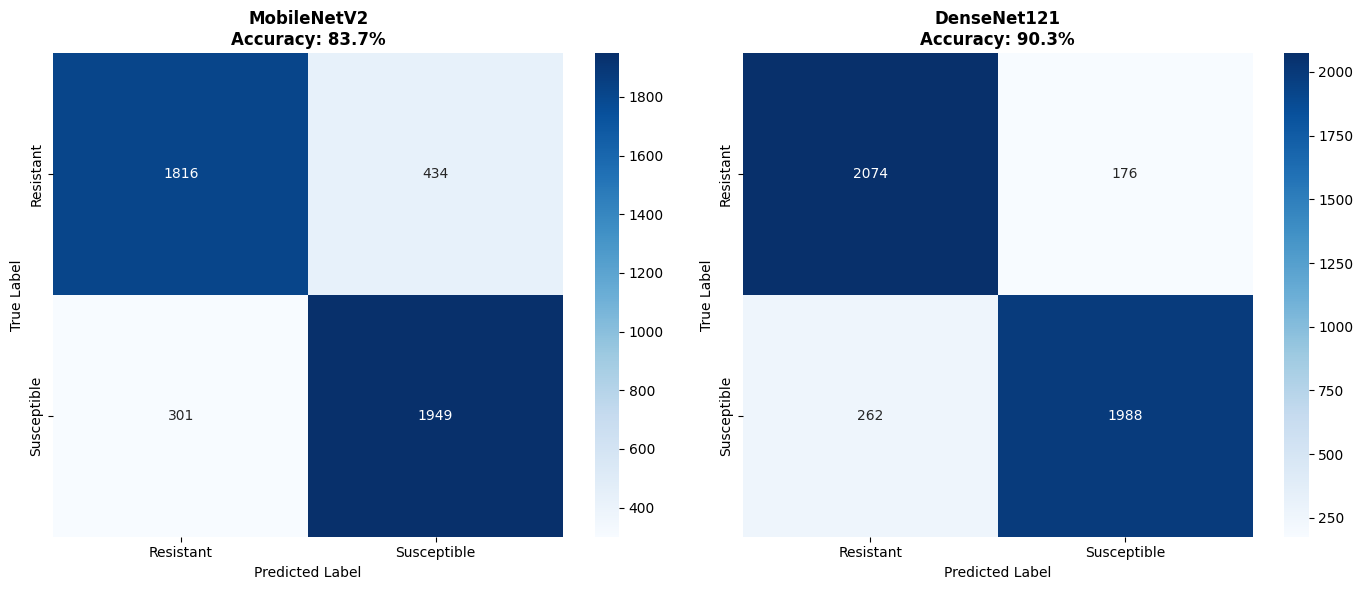

Confusion matrices saved


In [ ]:
# Confusion matrices
cm_mobile = confusion_matrix(y_test, y_pred_mobile)
cm_dense = confusion_matrix(y_test, y_pred_dense)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# MobileNetV2
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Resistant', 'Susceptible'],
            yticklabels=['Resistant', 'Susceptible'])
axes[0].set_title(f'MobileNetV2\nAccuracy: {results_mobile[1]*100:.1f}%', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# DenseNet121
sns.heatmap(cm_dense, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Resistant', 'Susceptible'],
            yticklabels=['Resistant', 'Susceptible'])
axes[1].set_title(f'DenseNet121\nAccuracy: {results_dense[1]*100:.1f}%', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved")

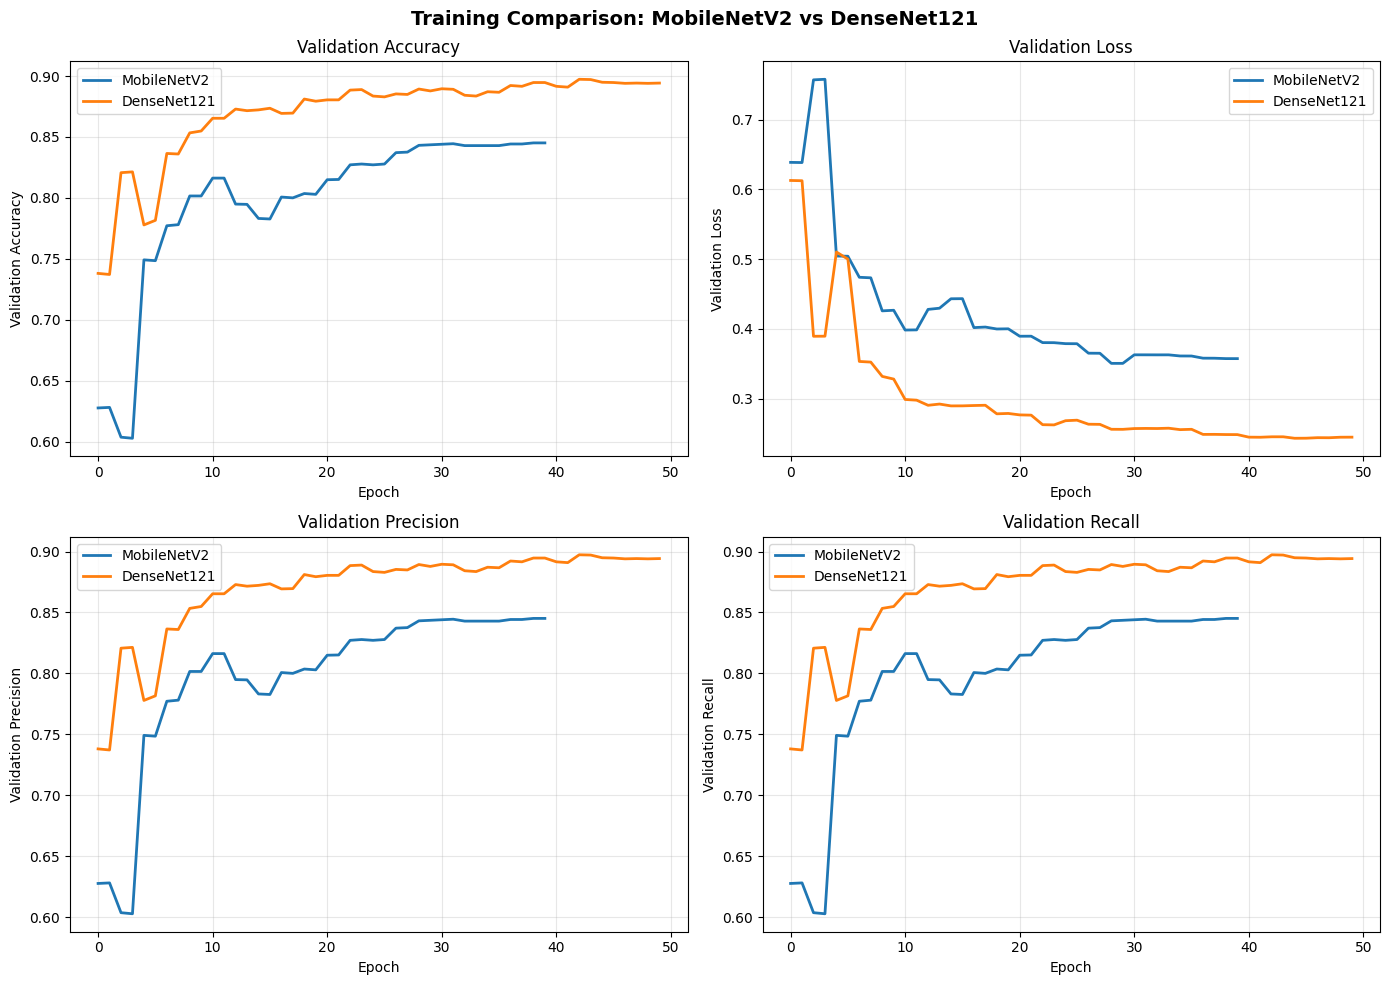

Training comparison plot saved


In [ ]:
# Training curves comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
axes[0, 0].plot(history_mobile.history['val_accuracy'], label='MobileNetV2', linewidth=2)
axes[0, 0].plot(history_dense.history['val_accuracy'], label='DenseNet121', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Validation Accuracy')
axes[0, 0].set_title('Validation Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Loss
axes[0, 1].plot(history_mobile.history['val_loss'], label='MobileNetV2', linewidth=2)
axes[0, 1].plot(history_dense.history['val_loss'], label='DenseNet121', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Validation Loss')
axes[0, 1].set_title('Validation Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision
axes[1, 0].plot(history_mobile.history['val_precision'], label='MobileNetV2', linewidth=2)
axes[1, 0].plot(history_dense.history['val_precision'], label='DenseNet121', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Precision')
axes[1, 0].set_title('Validation Precision')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Recall
axes[1, 1].plot(history_mobile.history['val_recall'], label='MobileNetV2', linewidth=2)
axes[1, 1].plot(history_dense.history['val_recall'], label='DenseNet121', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation Recall')
axes[1, 1].set_title('Validation Recall')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Comparison: MobileNetV2 vs DenseNet121', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'figures' / 'training_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training comparison plot saved")

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Part 11: Final Report

In [ ]:
report = f"""
COMPLETE TRAINING REPORT
{'='*70}

DATASET
{'-'*70}
Total cells extracted: {len(X_train) + len(X_val) + len(X_test)}
Training: {len(X_train)} ({np.sum(y_train==0)} resistant, {np.sum(y_train==1)} susceptible)
Validation: {len(X_val)} ({np.sum(y_val==0)} resistant, {np.sum(y_val==1)} susceptible)
Test: {len(X_test)} ({np.sum(y_test==0)} resistant, {np.sum(y_test==1)} susceptible)

MOBILENETV2 RESULTS
{'-'*70}
Test Accuracy: {results_mobile[1]*100:.2f}%
Precision: {results_mobile[2]:.4f}
Recall: {results_mobile[3]:.4f}
AUC: {results_mobile[4]:.4f}
Loss: {results_mobile[0]:.4f}

Per-class:
  Resistant:   Precision={precision_m[0]:.3f}, Recall={recall_m[0]:.3f}, F1={f1_m[0]:.3f}
  Susceptible: Precision={precision_m[1]:.3f}, Recall={recall_m[1]:.3f}, F1={f1_m[1]:.3f}

DENSENET121 RESULTS
{'-'*70}
Test Accuracy: {results_dense[1]*100:.2f}%
Precision: {results_dense[2]:.4f}
Recall: {results_dense[3]:.4f}
AUC: {results_dense[4]:.4f}
Loss: {results_dense[0]:.4f}

Per-class:
  Resistant:   Precision={precision_d[0]:.3f}, Recall={recall_d[0]:.3f}, F1={f1_d[0]:.3f}
  Susceptible: Precision={precision_d[1]:.3f}, Recall={recall_d[1]:.3f}, F1={f1_d[1]:.3f}

COMPARISON TO BASELINE PAPER
{'-'*70}
Paper (Zagajewski et al. 2023): 84% accuracy
MobileNetV2: {results_mobile[1]*100:.2f}%
DenseNet121: {results_dense[1]*100:.2f}%

FILES GENERATED
{'-'*70}
Models:
  - mobilenet_best.h5
  - mobilenet_final.h5
  - densenet_best.h5
  - densenet_final.h5

Data:
  - full_dataset_30k.npz
  - predictions_mobilenet.npz
  - predictions_densenet.npz
  - history_mobilenet.csv
  - history_densenet.csv
  - model_comparison.csv

Figures:
  - confusion_matrices.png
  - training_comparison.png

{'='*70}
TRAINING COMPLETE
{'='*70}
"""

print(report)

with open(OUTPUT_DIR / 'training_report.txt', 'w') as f:
    f.write(report)

print(f"\nReport saved to {OUTPUT_DIR / 'training_report.txt'}")


COMPLETE TRAINING REPORT

DATASET
----------------------------------------------------------------------
Total cells extracted: 30000
Training: 21000 (10500 resistant, 10500 susceptible)
Validation: 4500 (2250 resistant, 2250 susceptible)
Test: 4500 (2250 resistant, 2250 susceptible)

MOBILENETV2 RESULTS
----------------------------------------------------------------------
Test Accuracy: 83.67%
Precision: 0.8367
Recall: 0.8367
AUC: 0.9255
Loss: 0.3633

Per-class:
  Resistant:   Precision=0.858, Recall=0.807, F1=0.832
  Susceptible: Precision=0.818, Recall=0.866, F1=0.841

DENSENET121 RESULTS
----------------------------------------------------------------------
Test Accuracy: 90.27%
Precision: 0.9027
Recall: 0.9027
AUC: 0.9674
Loss: 0.2354

Per-class:
  Resistant:   Precision=0.888, Recall=0.922, F1=0.904
  Susceptible: Precision=0.919, Recall=0.884, F1=0.901

COMPARISON TO BASELINE PAPER
----------------------------------------------------------------------
Paper (Zagajewski et al. 